In [1]:
import numpy as np
import seaborn as sns
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib.ticker import FuncFormatter
from datetime import datetime

In [2]:
# force 'normal' text style for math text
mpl.rcParams['mathtext.default'] = 'regular'

# set global seaborn params
sns.set("paper", "ticks", color_codes=True, palette='colorblind')

## Loading Data

In [4]:
ts = pd.read_csv('/content/MOD-00684-a66ca9f3388247c8a9d38af32f80e58d.csv')
COLS_TO_INCLUDE = ['timestamp_local','bin0','bin1','bin2','bin3','bin4','bin5','pm25','co','o3','no','no2','rh','temp']
ts = ts[COLS_TO_INCLUDE]
ts.head()

,timestamp_local,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp
0,2025-12-31T18:59:42Z,11.578,0.908,0.229,0.048,0.052,0.018,8.018,828.982,25.941,2.560,33.422,49.4,0.1
1,2025-12-31T18:58:42Z,11.323,0.940,0.248,0.054,0.089,0.018,6.942,875.709,25.930,2.768,33.418,49.5,0.1
2,2025-12-31T18:57:42Z,12.160,1.016,0.181,0.042,0.057,0.037,8.970,1005.216,25.193,2.897,34.116,49.8,0.1
3,2025-12-31T18:56:42Z,12.582,1.044,0.287,0.041,0.042,0.028,7.627,909.765,23.749,2.896,34.814,50.1,0.1
4,2025-12-31T18:55:42Z,11.556,0.975,0.286,0.045,0.041,0.009,6.437,817.203,25.193,2.897,33.879,49.8,0.1


In [5]:
ts['timestamp_local'] = pd.to_datetime(ts['timestamp_local'],format="%Y-%m-%dT%H:%M:%SZ") #convert timestamp column to pandas timestamp format
ts.head()

,timestamp_local,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp
0,2025-12-31 18:59:42,11.578,0.908,0.229,0.048,0.052,0.018,8.018,828.982,25.941,2.560,33.422,49.4,0.1
1,2025-12-31 18:58:42,11.323,0.940,0.248,0.054,0.089,0.018,6.942,875.709,25.930,2.768,33.418,49.5,0.1
2,2025-12-31 18:57:42,12.160,1.016,0.181,0.042,0.057,0.037,8.970,1005.216,25.193,2.897,34.116,49.8,0.1
3,2025-12-31 18:56:42,12.582,1.044,0.287,0.041,0.042,0.028,7.627,909.765,23.749,2.896,34.814,50.1,0.1
4,2025-12-31 18:55:42,11.556,0.975,0.286,0.045,0.041,0.009,6.437,817.203,25.193,2.897,33.879,49.8,0.1


## Full Timeseries Plot

In [6]:
#taking daily average of ts. round to floor of the day
ts_day = ts.groupby(ts['timestamp_local'].dt.floor('d')).agg(bin0 = ('bin0','mean'),
                                                  bin1 = ('bin1','mean'),
                                                  bin2 = ('bin2','mean'),
                                                  bin3 = ('bin3','mean'),
                                                  bin4 = ('bin4','mean'),
                                                  bin5 = ('bin5','mean'),
                                                  pm25 = ('pm25','mean'),
                                                  co = ('co','mean'),
                                                  o3 = ('o3','mean'),
                                                  no = ('no','mean'),
                                                  no2 = ('no2','mean'),
                                                  rh = ('rh','mean'),
                                                  temp = ('temp','mean')).reset_index()

ts_day = ts_day.set_index('timestamp_local')
ts_day.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp
timestamp_local,,,,,,,,,,,,,
2025-03-31,29.911696,5.000933,1.651225,0.452354,0.586321,0.525229,9.199238,946.577104,35.911663,2.606454,34.844908,85.888750,16.443333
2025-04-01,7.131581,0.945702,0.249918,0.047415,0.051180,0.033230,2.600299,787.009841,46.935225,2.322310,18.010240,45.281944,12.292431
2025-04-02,5.583376,0.803257,0.439819,0.150492,0.212497,0.188012,4.007910,726.577335,49.003381,2.135643,27.718731,41.858264,8.290139
2025-04-03,26.799853,3.499103,1.205506,0.402385,0.591924,0.579397,11.450627,895.394594,32.770965,2.371063,29.458608,77.365278,15.877153
2025-04-04,7.347831,0.708301,0.252822,0.063342,0.084918,0.063344,4.349123,781.983539,42.932911,2.306285,18.338811,45.106389,20.812569


In [7]:
ts_day['pm25_c'] = 3.491 + 0.576*ts_day['pm25'] - 0.047*ts_day['rh'] + 0.070*ts_day['temp']
ts_day.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
timestamp_local,,,,,,,,,,,,,,
2025-03-31,29.911696,5.000933,1.651225,0.452354,0.586321,0.525229,9.199238,946.577104,35.911663,2.606454,34.844908,85.888750,16.443333,5.904023
2025-04-01,7.131581,0.945702,0.249918,0.047415,0.051180,0.033230,2.600299,787.009841,46.935225,2.322310,18.010240,45.281944,12.292431,3.720991
2025-04-02,5.583376,0.803257,0.439819,0.150492,0.212497,0.188012,4.007910,726.577335,49.003381,2.135643,27.718731,41.858264,8.290139,4.412527
2025-04-03,26.799853,3.499103,1.205506,0.402385,0.591924,0.579397,11.450627,895.394594,32.770965,2.371063,29.458608,77.365278,15.877153,7.561794
2025-04-04,7.347831,0.708301,0.252822,0.063342,0.084918,0.063344,4.349123,781.983539,42.932911,2.306285,18.338811,45.106389,20.812569,5.332974


<>:45: SyntaxWarning: invalid escape sequence '\m'
<>:45: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipython-input-514874767.py:45: SyntaxWarning: invalid escape sequence '\m'
  ax[5].set_ylabel("$PM_{2.5}$ [$\mu g m^{-3}$]",fontsize=14)


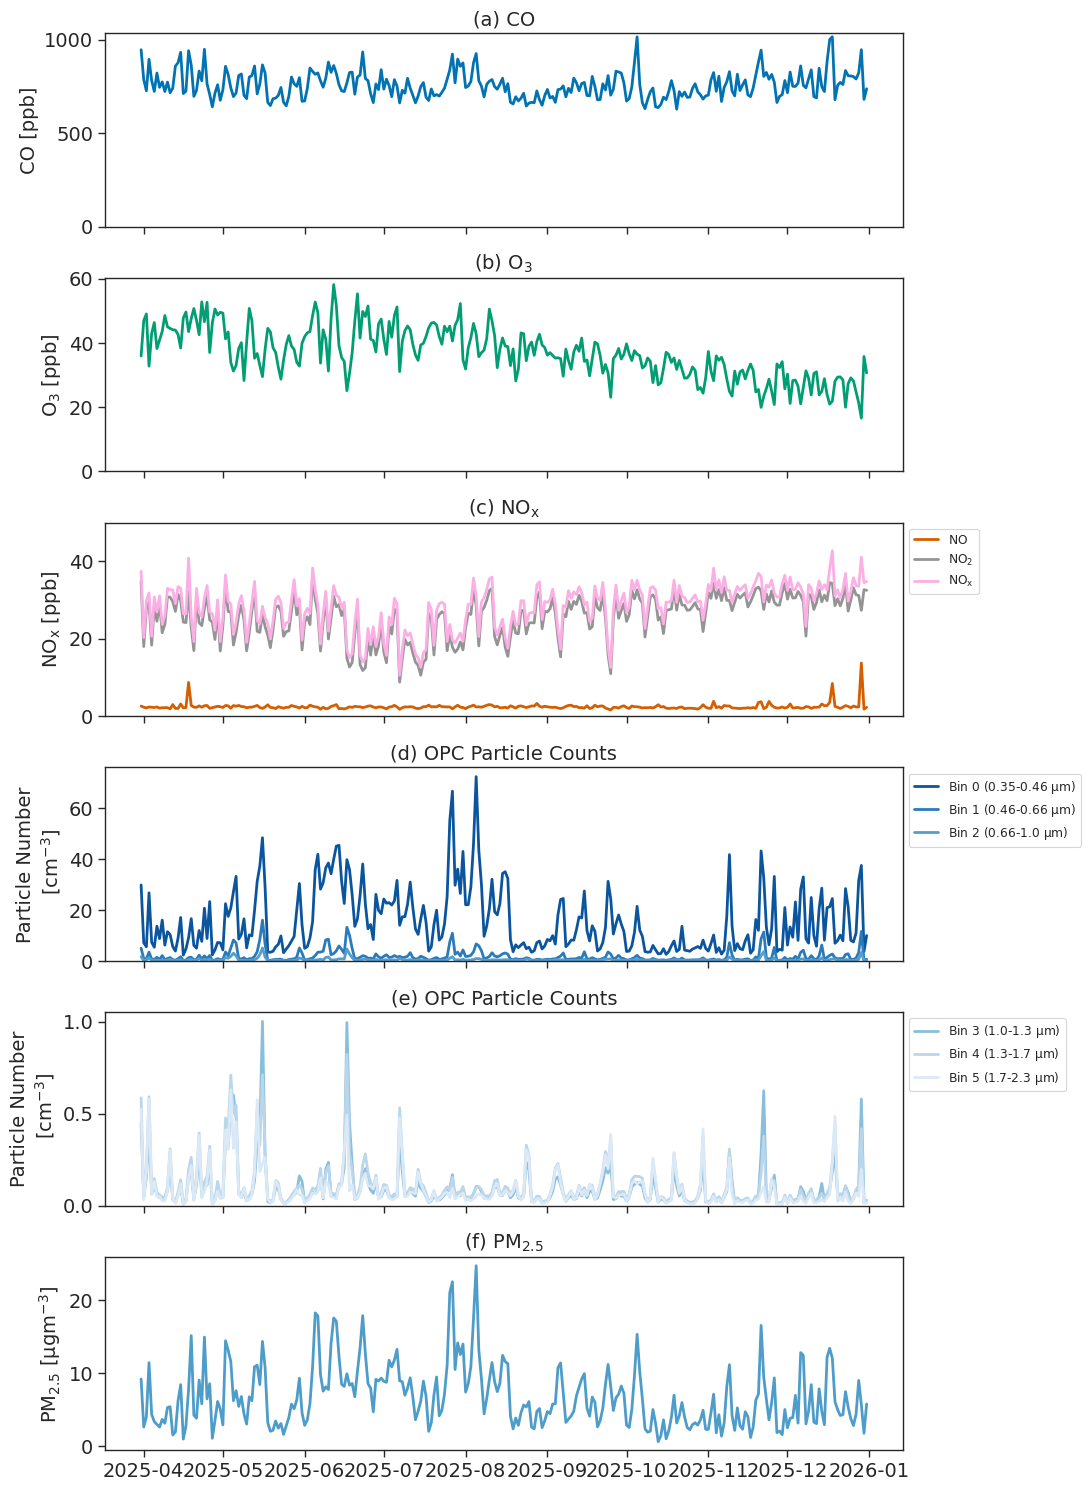

In [8]:
# set up the matplotlib figure
fig, ax = plt.subplots(nrows=6, ncols=1, figsize=(11, 15), sharex=True)

# grab the current color palette
cmap = sns.color_palette()

# plot the CO data and label the axis
ax[0].plot(ts_day['co'], lw=2, label="$CO$", color=sns.color_palette()[0])
ax[0].set_ylabel("CO [ppb]", fontsize=14)
ax[0].set_ylim(0, None)

# plot the o3 on the second axis
ax[1].plot(ts_day['o3'], lw=2, label="$O_3$", color=cmap[2])
ax[1].set_ylabel("$O_3$ [ppb]", fontsize=14)
ax[1].set_ylim(0, None)

#plot nox on the 2nd axis
ax[2].plot(ts_day['no'], lw=2, label="$NO$", color=cmap[3])
ax[2].plot(ts_day['no2'], lw=2, label="$NO_2$", color=cmap[7])
ax[2].plot(ts_day['no2']+ts_day['no'], lw=2, label="$NO_x$", color=cmap[6])
ax[2].set_ylabel("$NO_x$ [ppb]", fontsize=14)
ax[2].legend(fontsize = 14)
ax[2].set_ylim(0, 50)


# plot the OPC bins on the 5th and 6th rows
ax[3].plot(ts_day['bin0'], lw=2, label=r'Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
ax[3].plot(ts_day['bin1'], lw=2, label=r'Bin 1 (0.46-0.66 $\mu m$)', color=sns.color_palette("Blues_r", 6)[1])
ax[3].plot(ts_day['bin2'], lw=2, label=r'Bin 2 (0.66-1.0 $\mu m$)', color=sns.color_palette("Blues_r", 6)[2])
ax[3].set(ylim=(0, None))
ax[3].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=14)
ax[3].legend(fontsize = 14)


ax[4].plot(ts_day['bin3'], lw=2, label=r'Bin 3 (1.0-1.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[3])
ax[4].plot(ts_day['bin4'], lw=2, label=r'Bin 4 (1.3-1.7 $\mu m$)', color=sns.color_palette("Blues_r", 6)[4])
ax[4].plot(ts_day['bin5'], lw=2, label=r'Bin 5 (1.7-2.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[5])
ax[4].set(ylim=(0, None))
ax[4].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=14)
ax[4].legend(fontsize = 14)


#plot pm25 on the 6th row
ax[5].plot(ts_day['pm25'], lw=2, label = '$PM_{2.5}$ as reported', color=sns.color_palette()[0], alpha = 0.7)
ax[5].set_ylabel("$PM_{2.5}$ [$\mu g m^{-3}$]",fontsize=14)

# set titles for each panel
ax[0].set_title("(a) CO", fontsize=14)
ax[1].set_title("(b) $O_3$", fontsize=14)
ax[2].set_title("(c) $NO_x$", fontsize=14)
ax[3].set_title("(d) OPC Particle Counts", fontsize=14)
ax[4].set_title("(e) OPC Particle Counts", fontsize=14)
ax[5].set_title("(f) $PM_{2.5}$", fontsize=14)

ax[0].tick_params(axis='both', which='major', labelsize=14)
ax[1].tick_params(axis='both', which='major', labelsize=14)
ax[2].tick_params(axis='both', which='major', labelsize=14)
ax[3].tick_params(axis='both', which='major', labelsize=14)
ax[4].tick_params(axis='both', which='major', labelsize=14)
ax[5].tick_params(axis='both', which='major', labelsize=14)
ax[5].locator_params(axis='y', nbins=4)
ax[4].locator_params(axis='y', nbins=4)
ax[3].locator_params(axis='y', nbins=4)
ax[2].locator_params(axis='y', nbins=4)
ax[1].locator_params(axis='y', nbins=4)
ax[0].locator_params(axis='y', nbins=4)

# move legends
sns.move_legend(ax[2], "upper left", bbox_to_anchor=(1, 1))
sns.move_legend(ax[3], "upper left", bbox_to_anchor=(1, 1))
sns.move_legend(ax[4], "upper left", bbox_to_anchor=(1, 1))

# force a tight layout
plt.tight_layout()

# fig.savefig('C:/Users/alexa/Jupyter Notebook/MOD-00683/timeseries_MOD-00068.png')

## Dirunal Plots

In [9]:
#taking daily average of ts. round to floor of the day
ts_hour = ts.groupby(ts['timestamp_local'].dt.floor('h')).agg(bin0 = ('bin0','mean'),
                                                  bin1 = ('bin1','mean'),
                                                  bin2 = ('bin2','mean'),
                                                  bin3 = ('bin3','mean'),
                                                  bin4 = ('bin4','mean'),
                                                  bin5 = ('bin5','mean'),
                                                  pm25 = ('pm25','mean'),
                                                  co = ('co','mean'),
                                                  o3 = ('o3','mean'),
                                                  no = ('no','mean'),
                                                  no2 = ('no2','mean'),
                                                  rh = ('rh','mean'),
                                                  temp = ('temp','mean')).reset_index()

ts_hour = ts_hour.set_index('timestamp_local')
ts_hour.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp
timestamp_local,,,,,,,,,,,,,
2025-03-31 20:00:00,28.851783,3.353100,1.520233,0.516667,0.715500,0.652833,11.679433,861.858283,29.626400,1.833100,35.062267,80.276667,16.408333
2025-03-31 21:00:00,36.552150,4.989350,1.757317,0.530117,0.737433,0.705683,11.496300,1034.560750,30.424700,2.796200,39.783050,87.018333,16.211667
2025-03-31 22:00:00,31.164267,5.649967,1.746467,0.439517,0.537133,0.481833,8.031317,1084.971267,37.719567,2.894500,35.963700,88.690000,16.633333
2025-03-31 23:00:00,23.078583,6.011317,1.580883,0.323117,0.355217,0.260567,5.589900,804.918117,45.875983,2.902017,28.570617,87.570000,16.520000
2025-04-01 00:00:00,19.995350,3.694950,0.920183,0.203100,0.240950,0.162583,4.643717,715.655467,51.291600,2.829317,26.876650,85.415000,16.220000


In [10]:
ts_hour['pm25_c'] = 2.111 + 0.298*ts_hour['pm25'] + 0.024*ts_hour['rh'] + 0.050*ts_hour['temp']
ts_hour.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
timestamp_local,,,,,,,,,,,,,,
2025-03-31 20:00:00,28.851783,3.353100,1.520233,0.516667,0.715500,0.652833,11.679433,861.858283,29.626400,1.833100,35.062267,80.276667,16.408333,8.338528
2025-03-31 21:00:00,36.552150,4.989350,1.757317,0.530117,0.737433,0.705683,11.496300,1034.560750,30.424700,2.796200,39.783050,87.018333,16.211667,8.435921
2025-03-31 22:00:00,31.164267,5.649967,1.746467,0.439517,0.537133,0.481833,8.031317,1084.971267,37.719567,2.894500,35.963700,88.690000,16.633333,7.464559
2025-03-31 23:00:00,23.078583,6.011317,1.580883,0.323117,0.355217,0.260567,5.589900,804.918117,45.875983,2.902017,28.570617,87.570000,16.520000,6.704470
2025-04-01 00:00:00,19.995350,3.694950,0.920183,0.203100,0.240950,0.162583,4.643717,715.655467,51.291600,2.829317,26.876650,85.415000,16.220000,6.355788


In [11]:
#prepping data
ts_hour['Hour'] = ts_hour.index.hour
ts_hour.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c,Hour
timestamp_local,,,,,,,,,,,,,,,
2025-03-31 20:00:00,28.851783,3.353100,1.520233,0.516667,0.715500,0.652833,11.679433,861.858283,29.626400,1.833100,35.062267,80.276667,16.408333,8.338528,20
2025-03-31 21:00:00,36.552150,4.989350,1.757317,0.530117,0.737433,0.705683,11.496300,1034.560750,30.424700,2.796200,39.783050,87.018333,16.211667,8.435921,21
2025-03-31 22:00:00,31.164267,5.649967,1.746467,0.439517,0.537133,0.481833,8.031317,1084.971267,37.719567,2.894500,35.963700,88.690000,16.633333,7.464559,22
2025-03-31 23:00:00,23.078583,6.011317,1.580883,0.323117,0.355217,0.260567,5.589900,804.918117,45.875983,2.902017,28.570617,87.570000,16.520000,6.704470,23
2025-04-01 00:00:00,19.995350,3.694950,0.920183,0.203100,0.240950,0.162583,4.643717,715.655467,51.291600,2.829317,26.876650,85.415000,16.220000,6.355788,0


In [12]:
#groupping by hour and calculate the mean
diurnal_data = ts_hour.groupby('Hour').mean()
diurnal_data.index = diurnal_data.index.map(lambda x: "{:02d}:00".format(x))
diurnal_data

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
Hour,,,,,,,,,,,,,,
00:00,15.804306,2.259517,0.606176,0.120127,0.129032,0.100977,6.694683,775.322379,34.246951,2.306475,27.294361,62.360189,16.687643,6.437042
01:00,16.084720,2.204670,0.562884,0.111488,0.123197,0.099772,6.525556,762.782733,33.435785,2.198635,27.345506,63.755112,16.316889,6.401583
02:00,16.244744,2.093430,0.531835,0.109767,0.123212,0.100799,6.356319,757.965558,32.470343,2.129121,27.512066,65.183672,15.947291,6.366956
03:00,16.360490,2.117119,0.528497,0.109680,0.123241,0.102010,6.197704,746.237227,31.674847,2.108872,27.359266,66.342675,15.598989,6.330089
04:00,16.542241,2.160394,0.536517,0.112674,0.125884,0.101894,6.178662,746.477641,30.824688,2.094497,26.801406,67.455523,15.288380,6.335593
05:00,16.808137,2.262564,0.590165,0.126043,0.136703,0.105999,6.171459,754.365519,29.494401,2.122247,27.272969,68.437924,15.060128,6.345611
06:00,17.088636,2.255213,0.580396,0.122698,0.136622,0.109973,6.385532,773.171295,28.162909,2.368035,27.800181,68.299386,15.127214,6.409435
07:00,16.859445,2.102686,0.550059,0.120508,0.138571,0.112598,6.715161,789.346150,28.219121,2.888938,26.019806,64.601815,16.091484,6.467136
08:00,16.412931,1.951947,0.503727,0.105816,0.125651,0.101441,7.030999,782.554497,29.610181,3.154655,23.646395,58.709830,17.925600,6.511554


<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:27: SyntaxWarning: invalid escape sequence '\m'
<>:28: SyntaxWarning: invalid escape sequence '\m'
<>:34: SyntaxWarning: invalid escape sequence '\m'
<>:35: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:27: SyntaxWarning: invalid escape sequence '\m'
<>:28: SyntaxWarning: invalid escape sequence '\m'
<>:34: SyntaxWarning: invalid escape sequence '\m'
<>:35: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipython-input-52676365.py:26: SyntaxWarning: invalid escape sequence '\m'
  ax[3].plot(diurnal_data['bin0'], lw=2, label='Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
/tmp/ipython-input-52676365.py:27: SyntaxWarning: invalid escape sequence '\m'
  ax[3].plot(diurnal_data['bin1'], lw=2, label='Bin 1 (0.46-0.66 $\mu m$)', color=sns.color_palette("Blues_r", 6

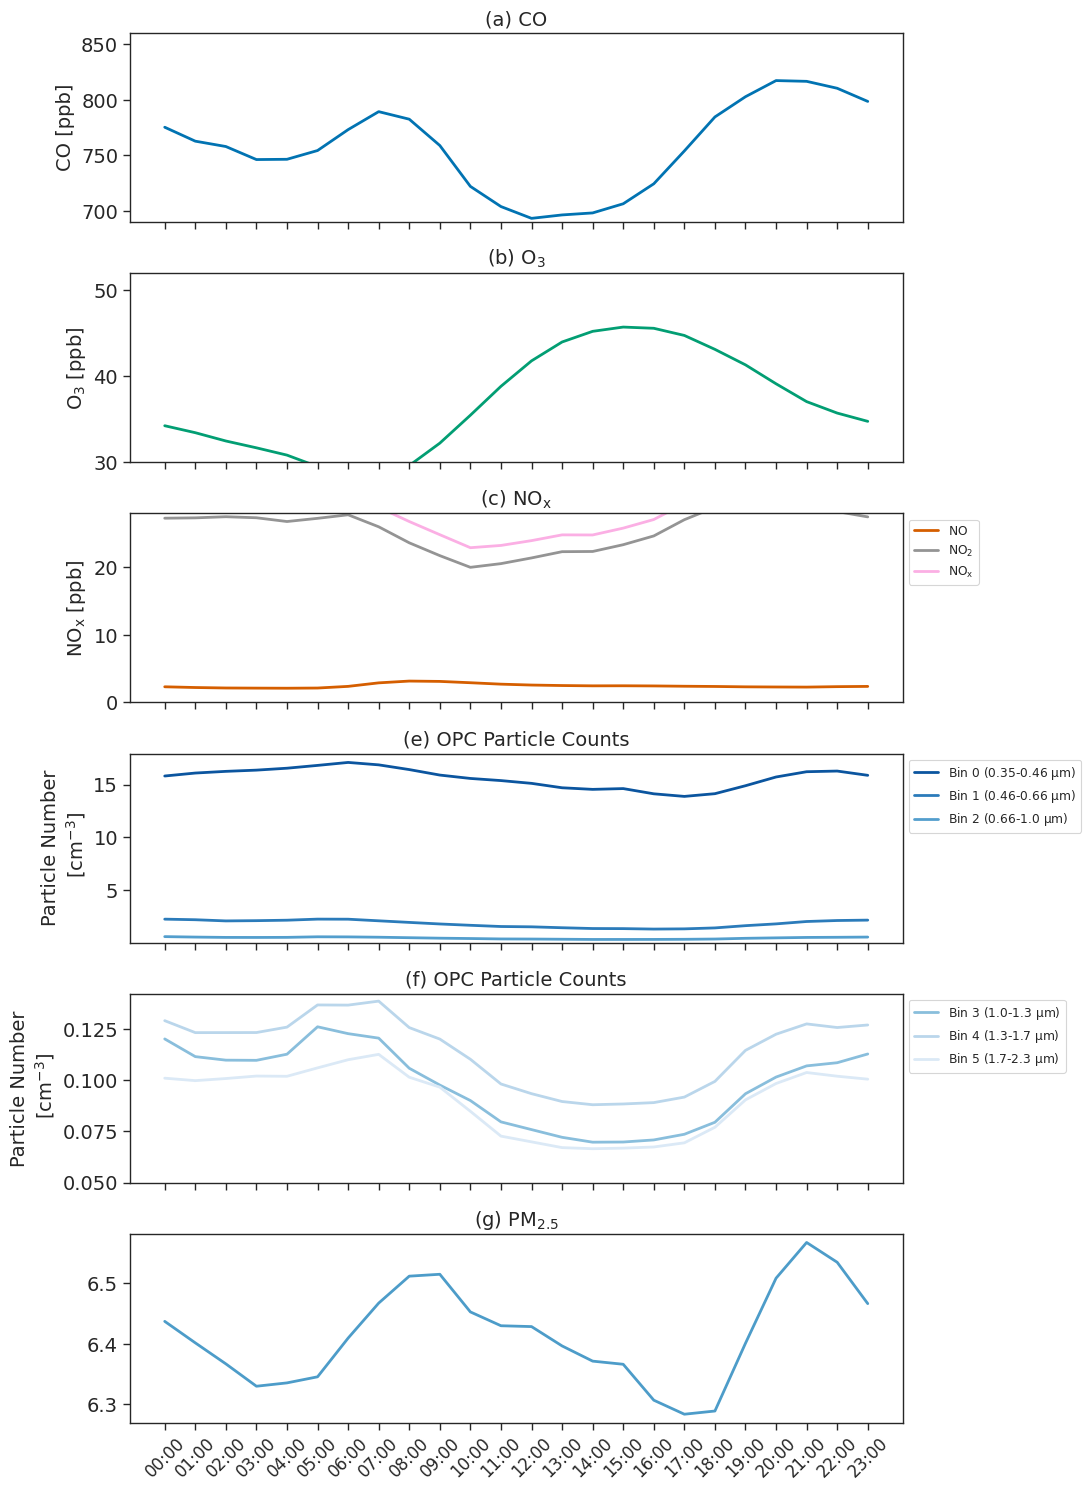

In [13]:
# set up the matplotlib figure
fig, ax = plt.subplots(nrows=6, ncols=1, figsize=(11, 15), sharex=True)

# grab the current color palette
cmap = sns.color_palette()

# plot the CO data and label the axis
ax[0].plot(diurnal_data['co'], lw=2, label="$CO$", color=sns.color_palette()[0])
ax[0].set_ylabel("CO [ppb]", fontsize=14)
ax[0].set_ylim(690, 860)

# plot the o3 on the first axis
ax[1].plot(diurnal_data['o3'], lw=2, label="$O_3$", color=cmap[2])
ax[1].set_ylabel("$O_3$ [ppb]", fontsize=14)
ax[1].set_ylim(30, 52)

#plot nox on the 2nd axis
ax[2].plot(diurnal_data['no'], lw=2, label="$NO$", color=cmap[3])
ax[2].plot(diurnal_data['no2'], lw=2, label="$NO_2$", color=cmap[7])
ax[2].plot(diurnal_data['no2']+diurnal_data['no'], lw=2, label="$NO_x$", color=cmap[6])
ax[2].set_ylabel("$NO_x$ [ppb]", fontsize=14)
ax[2].legend(fontsize = 14)
ax[2].set_ylim(0, 28)

# plot the OPC bins on the 3rd and 4th rows
ax[3].plot(diurnal_data['bin0'], lw=2, label='Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
ax[3].plot(diurnal_data['bin1'], lw=2, label='Bin 1 (0.46-0.66 $\mu m$)', color=sns.color_palette("Blues_r", 6)[1])
ax[3].plot(diurnal_data['bin2'], lw=2, label='Bin 2 (0.66-1.0 $\mu m$)', color=sns.color_palette("Blues_r", 6)[2])
ax[3].set(ylim=(0.05, None))
ax[3].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=14)
ax[3].legend(fontsize = 14)


ax[4].plot(diurnal_data['bin3'], lw=2, label='Bin 3 (1.0-1.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[3])
ax[4].plot(diurnal_data['bin4'], lw=2, label='Bin 4 (1.3-1.7 $\mu m$)', color=sns.color_palette("Blues_r", 6)[4])
ax[4].plot(diurnal_data['bin5'], lw=2, label='Bin 5 (1.7-2.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[5])
ax[4].set(ylim=(0.05, None))
ax[4].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=14)
ax[4].legend(fontsize = 14)


#plot pm25 on the 6th row
ax[5].plot(diurnal_data['pm25_c'], lw=2, label = '$PM_{2.5}$ as reported', color=sns.color_palette()[0], alpha = 0.7)

# set titles for each panel
ax[0].set_title("(a) CO", fontsize=14)
ax[1].set_title("(b) $O_3$", fontsize=14)
ax[2].set_title("(c) $NO_x$", fontsize=14)
ax[3].set_title("(e) OPC Particle Counts", fontsize=14)
ax[4].set_title("(f) OPC Particle Counts", fontsize=14)
ax[5].set_title("(g) $PM_{2.5}$", fontsize=14)

ax[0].tick_params(axis='both', which='major', labelsize=14)
ax[1].tick_params(axis='both', which='major', labelsize=14)
ax[2].tick_params(axis='both', which='major', labelsize=14)
ax[3].tick_params(axis='both', which='major', labelsize=14)
ax[4].tick_params(axis='both', which='major', labelsize=14)
ax[5].tick_params(axis='both', which='major', labelsize=14)
ax[5].locator_params(axis='y', nbins=4)
ax[4].locator_params(axis='y', nbins=4)
ax[3].locator_params(axis='y', nbins=4)
ax[2].locator_params(axis='y', nbins=4)
ax[1].locator_params(axis='y', nbins=4)
ax[0].locator_params(axis='y', nbins=4)

# set x as hours
ax[5].set_xticks(range(24))
ax[5].set_xticklabels([f"{h:02d}:00" for h in range(24)], rotation=45)

# move legends
sns.move_legend(ax[2], "upper left", bbox_to_anchor=(1, 1))
sns.move_legend(ax[3], "upper left", bbox_to_anchor=(1, 1))
sns.move_legend(ax[4], "upper left", bbox_to_anchor=(1, 1))

plt.xticks(range(0, 24), size = 12)
plt.xticks(rotation=45)

# force a tight layout
plt.tight_layout()

# fig.savefig('C:/Users/alexa/Jupyter Notebook/MOD-00683/dirunal_MOD-00068_allfeatures.png')

## Diurnal by Season

In [14]:
def month_to_season(month):
    if 3 <= month <= 5:
        return 'Spring'
    elif 6 <= month <= 8:
        return 'Summer'
    elif 9 <= month <= 11:
        return 'Autumn'
    else:
        return 'Winter'

In [15]:
ts_hour = ts_hour.reset_index()

In [16]:
#prepping data
ts_hour['Season'] = ts_hour['timestamp_local'].dt.month.apply(month_to_season)
ts_hour.head()

,timestamp_local,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c,Hour,Season
0,2025-03-31 20:00:00,28.851783,3.353100,1.520233,0.516667,0.715500,0.652833,11.679433,861.858283,29.626400,1.833100,35.062267,80.276667,16.408333,8.338528,20,Spring
1,2025-03-31 21:00:00,36.552150,4.989350,1.757317,0.530117,0.737433,0.705683,11.496300,1034.560750,30.424700,2.796200,39.783050,87.018333,16.211667,8.435921,21,Spring
2,2025-03-31 22:00:00,31.164267,5.649967,1.746467,0.439517,0.537133,0.481833,8.031317,1084.971267,37.719567,2.894500,35.963700,88.690000,16.633333,7.464559,22,Spring
3,2025-03-31 23:00:00,23.078583,6.011317,1.580883,0.323117,0.355217,0.260567,5.589900,804.918117,45.875983,2.902017,28.570617,87.570000,16.520000,6.704470,23,Spring
4,2025-04-01 00:00:00,19.995350,3.694950,0.920183,0.203100,0.240950,0.162583,4.643717,715.655467,51.291600,2.829317,26.876650,85.415000,16.220000,6.355788,0,Spring


In [17]:
grouped_by_season_hour = ts_hour.drop(columns='timestamp_local').groupby(['Season', 'Hour']).mean()
grouped_by_season_hour

bin0      bin1      bin2      bin3      bin4      bin5  \
Season Hour                                                                
Autumn 0      9.672596  1.431322  0.456390  0.094747  0.102165  0.082287   
       1     10.137676  1.231094  0.362636  0.077017  0.091874  0.081880   
       2     10.492209  1.188456  0.349482  0.077818  0.094074  0.086283   
       3     11.065381  1.284135  0.364410  0.081606  0.097413  0.088635   
       4     11.485364  1.298424  0.330514  0.070368  0.084975  0.077796   
...                ...       ...       ...       ...       ...       ...   
Winter 19    16.567156  1.729309  0.421779  0.071319  0.073785  0.051342   
       20    17.142507  1.831823  0.446070  0.076190  0.078124  0.054363   
       21    17.530880  2.039767  0.502071  0.086995  0.085892  0.060194   
       22    18.471580  2.384032  0.554018  0.098828  0.099092  0.068165   
       23    19.160954  2.597949  0.553364  0.090671  0.090513  0.068213   

                 pm25          co         o3        no        no2         rh  \
Season Hour                                                                    
Autumn 0     4.985384  754.024808  30.680324  2.421999  29.401285  61.343389   
       1     4.955995  747.495602  29.585177  2.192012  29.010573  63.350441   
       2     4.911565  746.311471  28.879794  2.058891  29.841154  64.925204   
       3     4.868904  736.641542  28.270086  2.045683  29.974330  66.403354   
       4     4.652461  739.586019  27.607566  2.046446  29.085707  67.448365   
...               ...         ...        ...       ...        ...        ...   
Winter 19    6.358229  811.351826  25.869556  2.262052  32.374710  56.431322   
       20    6.413236  808.338511  25.428076  2.354229  32.174630  57.135345   
       21    6.318905  795.834488  25.234795  2.355642  32.176998  57.956782   
       22    6.331332  791.494909  25.031748  2.386317  32.059364  59.533736   
       23    6.352944  808.697079  24.741174  2.481994  31.912158  60.984138   

                  temp    pm25_c  
Season Hour                       
Autumn 0     15.167667  5.827269  
       1     14.732103  5.844902  
       2     14.363889  5.851046  
       3     14.036841  5.857456  
       4     13.751494  5.803769  
...                ...       ...  
Winter 19     2.230057  5.471607  
       20     1.987414  5.492763  
       21     1.819885  5.475991  
       22     1.653736  5.509233  
       23     1.440805  5.539837  

[96 rows x 14 columns]

In [18]:
grouped_by_season_hour = grouped_by_season_hour.reset_index()
grouped_by_season_hour

,Season,Hour,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
0,Autumn,0,9.672596,1.431322,0.456390,0.094747,0.102165,0.082287,4.985384,754.024808,30.680324,2.421999,29.401285,61.343389,15.167667,5.827269
1,Autumn,1,10.137676,1.231094,0.362636,0.077017,0.091874,0.081880,4.955995,747.495602,29.585177,2.192012,29.010573,63.350441,14.732103,5.844902
2,Autumn,2,10.492209,1.188456,0.349482,0.077818,0.094074,0.086283,4.911565,746.311471,28.879794,2.058891,29.841154,64.925204,14.363889,5.851046
3,Autumn,3,11.065381,1.284135,0.364410,0.081606,0.097413,0.088635,4.868904,736.641542,28.270086,2.045683,29.974330,66.403354,14.036841,5.857456
4,Autumn,4,11.485364,1.298424,0.330514,0.070368,0.084975,0.077796,4.652461,739.586019,27.607566,2.046446,29.085707,67.448365,13.751494,5.803769
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,Winter,19,16.567156,1.729309,0.421779,0.071319,0.073785,0.051342,6.358229,811.351826,25.869556,2.262052,32.374710,56.431322,2.230057,5.471607
92,Winter,20,17.142507,1.831823,0.446070,0.076190,0.078124,0.054363,6.413236,808.338511,25.428076,2.354229,32.174630,57.135345,1.987414,5.492763
93,Winter,21,17.530880,2.039767,0.502071,0.086995,0.085892,0.060194,6.318905,795.834488,25.234795,2.355642,32.176998,57.956782,1.819885,5.475991
94,Winter,22,18.471580,2.384032,0.554018,0.098828,0.099092,0.068165,6.331332,791.494909,25.031748,2.386317,32.059364,59.533736,1.653736,5.509233


In [19]:
autumn_diurnal = grouped_by_season_hour[grouped_by_season_hour['Season'] == 'Autumn']
winter_diurnal = grouped_by_season_hour[grouped_by_season_hour['Season'] == 'Winter']
spring_diurnal = grouped_by_season_hour[grouped_by_season_hour['Season'] == 'Spring']
summer_diurnal = grouped_by_season_hour[grouped_by_season_hour['Season'] == 'Summer']

autumn_diurnal.index = autumn_diurnal.index.map(lambda x: "{:02d}:00".format(x%24))
winter_diurnal.index = winter_diurnal.index.map(lambda x: "{:02d}:00".format(x%24))
spring_diurnal.index = spring_diurnal.index.map(lambda x: "{:02d}:00".format(x%24))
summer_diurnal.index = summer_diurnal.index.map(lambda x: "{:02d}:00".format(x%24))

In [20]:
autumn_diurnal

,Season,Hour,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
00:00,Autumn,0,9.672596,1.431322,0.456390,0.094747,0.102165,0.082287,4.985384,754.024808,30.680324,2.421999,29.401285,61.343389,15.167667,5.827269
01:00,Autumn,1,10.137676,1.231094,0.362636,0.077017,0.091874,0.081880,4.955995,747.495602,29.585177,2.192012,29.010573,63.350441,14.732103,5.844902
02:00,Autumn,2,10.492209,1.188456,0.349482,0.077818,0.094074,0.086283,4.911565,746.311471,28.879794,2.058891,29.841154,64.925204,14.363889,5.851046
03:00,Autumn,3,11.065381,1.284135,0.364410,0.081606,0.097413,0.088635,4.868904,736.641542,28.270086,2.045683,29.974330,66.403354,14.036841,5.857456
04:00,Autumn,4,11.485364,1.298424,0.330514,0.070368,0.084975,0.077796,4.652461,739.586019,27.607566,2.046446,29.085707,67.448365,13.751494,5.803769
05:00,Autumn,5,11.995367,1.472407,0.387615,0.079640,0.089776,0.078929,4.683097,745.954625,26.463972,2.046390,29.642430,68.701167,13.546444,5.832713
06:00,Autumn,6,12.684066,1.624704,0.439534,0.089891,0.098662,0.082556,4.923170,761.965800,24.872567,2.219760,30.426898,69.726960,13.398571,5.921480
07:00,Autumn,7,12.747990,1.453249,0.387902,0.081685,0.094182,0.079820,5.173888,784.150667,24.776181,2.355925,30.267760,67.622885,13.939517,5.972744
08:00,Autumn,8,11.979265,1.262366,0.351917,0.078488,0.097093,0.081963,5.644330,785.016233,26.036708,2.504987,26.662486,60.952582,15.948553,6.053300
09:00,Autumn,9,10.693382,1.126175,0.330636,0.076198,0.096762,0.080077,5.620137,748.592378,28.358482,2.644266,23.355501,53.810018,18.212729,5.987878


In [21]:
seasons_order = [winter_diurnal, spring_diurnal, summer_diurnal, autumn_diurnal]

<>:40: SyntaxWarning: invalid escape sequence '\m'
<>:41: SyntaxWarning: invalid escape sequence '\m'
<>:42: SyntaxWarning: invalid escape sequence '\m'
<>:48: SyntaxWarning: invalid escape sequence '\m'
<>:49: SyntaxWarning: invalid escape sequence '\m'
<>:50: SyntaxWarning: invalid escape sequence '\m'
<>:56: SyntaxWarning: invalid escape sequence '\m'
<>:40: SyntaxWarning: invalid escape sequence '\m'
<>:41: SyntaxWarning: invalid escape sequence '\m'
<>:42: SyntaxWarning: invalid escape sequence '\m'
<>:48: SyntaxWarning: invalid escape sequence '\m'
<>:49: SyntaxWarning: invalid escape sequence '\m'
<>:50: SyntaxWarning: invalid escape sequence '\m'
<>:56: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipython-input-1297212592.py:40: SyntaxWarning: invalid escape sequence '\m'
  ax[3,i].plot(seasons_order[i]['bin0'], lw=2, label='Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
/tmp/ipython-input-1297212592.py:41: SyntaxWarning: invalid escape sequence '\m'


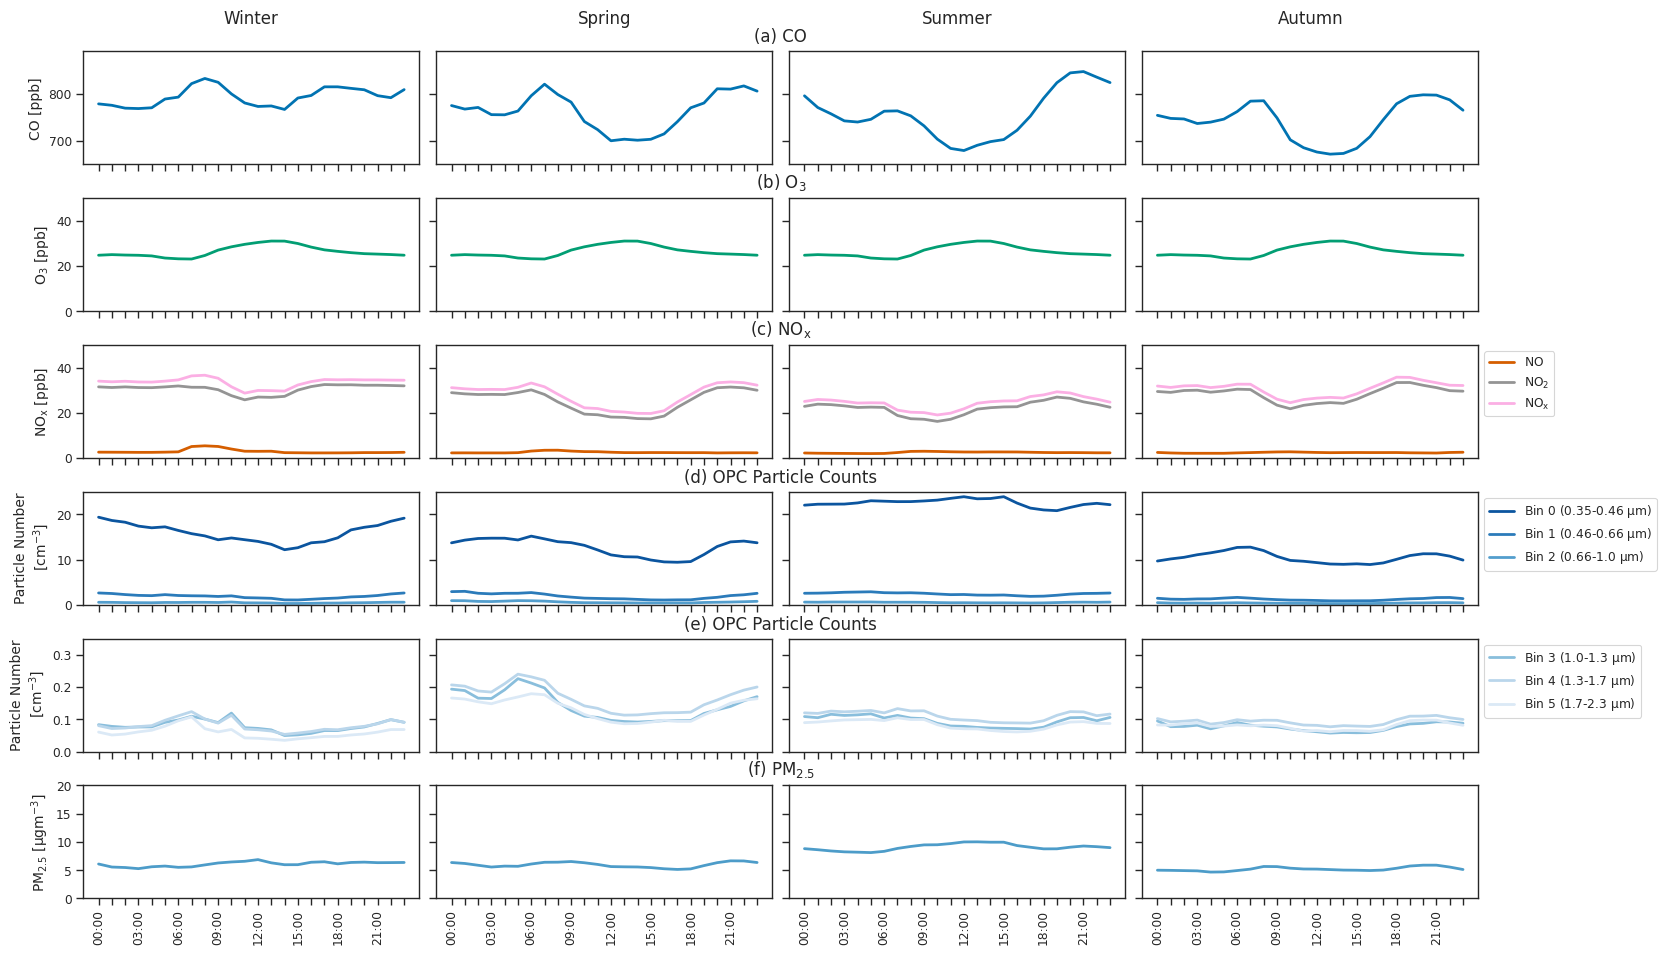

In [23]:
# set up the matplotlib figure
fig, ax = plt.subplots(nrows=6, ncols=4, figsize=(18,11), sharex=True)
plt.subplots_adjust(hspace = 0.3, wspace = 0.05)

# grab the current color palette
cmap = sns.color_palette()

#iterate through seasons
for i in range(len(seasons_order)):

    #set ax column labels as season
    ax[0,0].set_title("Winter", fontsize=12, pad = 20)
    ax[0,1].set_title("Spring", fontsize=12, pad = 20)
    ax[0,2].set_title("Summer", fontsize=12, pad = 20)
    ax[0,3].set_title("Autumn", fontsize=12, pad = 20)

    # plot the CO data and label the axis
    ax[0,0].set_ylabel("CO [ppb]", fontsize=10)
    ax[0,i].plot(seasons_order[i]['co'], lw=2, label="$CO$", color=sns.color_palette()[0])
    ax[0,i].set_ylim(650, 890)
    ax[0,i].set_xticks(range(0, 2))
    ax[0,i].set_xticks(seasons_order[i].index)

    # plot the o3 on the second axis
    ax[1,0].set_ylabel("$O_3$ [ppb]", fontsize=10)
    ax[1,i].plot(winter_diurnal['o3'], lw=2, label="$O_3$", color=cmap[2])
    ax[1,i].set_ylim(0, 50)

    #plot nox on the 3rd axis
    ax[2,0].set_ylabel("$NO_x$ [ppb]", fontsize=10)
    ax[2,i].plot(seasons_order[i]['no'], lw=2, label="$NO$", color=cmap[3])
    ax[2,i].plot(seasons_order[i]['no2'], lw=2, label="$NO_2$", color=cmap[7])
    ax[2,i].plot(seasons_order[i]['no2']+seasons_order[i]['no'], lw=2, label="$NO_x$", color=cmap[6])
    ax[2,i].set_ylim(0, 50)
    ax[2,3].legend(fontsize = 14)
    sns.move_legend(ax[2,3], "upper left", bbox_to_anchor=(1, 1))

    # plot the OPC bins on the 4th and 5th rows
    ax[3,0].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=10)
    ax[3,i].plot(seasons_order[i]['bin0'], lw=2, label='Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
    ax[3,i].plot(seasons_order[i]['bin1'], lw=2, label='Bin 1 (0.46-0.66 $\mu m$)', color=sns.color_palette("Blues_r", 6)[1])
    ax[3,i].plot(seasons_order[i]['bin2'], lw=2, label='Bin 2 (0.66-1.0 $\mu m$)', color=sns.color_palette("Blues_r", 6)[2])
    ax[3,i].set(ylim=(0, 25))
    ax[3,3].legend(fontsize = 14)
    sns.move_legend(ax[3,3], "upper left", bbox_to_anchor=(1, 1))

    ax[4,0].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=10)
    ax[4,i].plot(seasons_order[i]['bin3'], lw=2, label='Bin 3 (1.0-1.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[3])
    ax[4,i].plot(seasons_order[i]['bin4'], lw=2, label='Bin 4 (1.3-1.7 $\mu m$)', color=sns.color_palette("Blues_r", 6)[4])
    ax[4,i].plot(seasons_order[i]['bin5'], lw=2, label='Bin 5 (1.7-2.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[5])
    ax[4,i].set(ylim=(0, 0.35))
    ax[4,3].legend(fontsize = 14)
    sns.move_legend(ax[4,3], "upper left", bbox_to_anchor=(1, 1))

    #plot pm25 on the 6th row
    ax[5,0].set_ylabel("$PM_{2.5}$ [$\mu g m^{-3}$]",fontsize=10)
    ax[5,i].plot(seasons_order[i]['pm25'], lw=2, label = '$PM_{2.5}$ as reported', color=sns.color_palette()[0], alpha = 0.7)
    ax[5,i].set(ylim=(0, 20))
    ax[5,i].set_xticklabels(['00:00','','','03:00','','','06:00','','','09:00','','','12:00','','','15:00','','','18:00','','','21:00','',''], rotation=90)

    #remove subplot y ticks for subplots beyond winter
    if i>0:
        for j in range(6):
            ax[j,i].set_yticklabels([])

    # set titles for each panel
    row_titles = [
    "(a) CO",
    "(b) $O_3$",
    "(c) $NO_x$",
    "(d) OPC Particle Counts",
    "(e) OPC Particle Counts",
    "(f) $PM_{2.5}$"
]

for r, title in enumerate(row_titles):

    # left and right subplot positions
    left = ax[r,0].get_position()
    right = ax[r,-1].get_position()

    # horizontal center between first and last column
    x_center = (left.x0 + right.x1) / 2

    # slightly above the row
    y_top = left.y1 + 0.005

    fig.text(
        x_center,
        y_top,
        title,
        ha='center',
        va='bottom',
        fontsize=12
    )

# fig.savefig('C:/Users/alexa/Jupyter Notebook/MOD-00683/diurnal_by_season_MOD-000683.png')